In [1]:
import pandas as pd

In [2]:
df_population_row = pd.read_csv('population.csv')

In [3]:
# first look at the dataframe
df_population_row

,Country Name,Country Code,Year,Value
0,Aruba,ABW,1960,54922
1,Aruba,ABW,1961,55578
2,Aruba,ABW,1962,56320
3,Aruba,ABW,1963,57002
4,Aruba,ABW,1964,57619
...,...,...,...,...
17190,Zimbabwe,ZWE,2020,15526888
17191,Zimbabwe,ZWE,2021,15797210
17192,Zimbabwe,ZWE,2022,16069056
17193,Zimbabwe,ZWE,2023,16340822


# 1 Making a pivot table

### .pivot() : Return reshaped Dataframe organized by the given index / columns values("pivot without aggregation")

In [4]:
# droping a null value
df_population_row.dropna(inplace=True)

In [5]:
# making a pivot table
df_pivot = df_population_row.pivot(index='Year',
                                    columns='Country Name',
                                    values='Value')

In [6]:
df_pivot.columns

Index(['Afghanistan', 'Africa Eastern and Southern',
       'Africa Western and Central', 'Albania', 'Algeria', 'American Samoa',
       'Andorra', 'Angola', 'Antigua and Barbuda', 'Arab World',
       ...
       'Uzbekistan', 'Vanuatu', 'Venezuela, RB', 'Viet Nam',
       'Virgin Islands (U.S.)', 'West Bank and Gaza', 'World', 'Yemen, Rep.',
       'Zambia', 'Zimbabwe'],
      dtype='object', name='Country Name', length=265)

In [7]:
# selecting some contries
df_pivot = df_pivot[['India','China','Andorra','Afghanistan']]

In [8]:
# showing pivot table
df_pivot

Country Name,India,China,Andorra,Afghanistan
Year,,,,
1960,4.359903e+08,6.670700e+08,9510.0,9035043.0
1961,4.465647e+08,6.603300e+08,10283.0,9214083.0
1962,4.572831e+08,6.657700e+08,11086.0,9404406.0
1963,4.681386e+08,6.823350e+08,11915.0,9604487.0
1964,4.792296e+08,6.983550e+08,12764.0,9814318.0
...,...,...,...,...
2020,1.402618e+09,1.411100e+09,77380.0,39068979.0
2021,1.414204e+09,1.412360e+09,78364.0,40000412.0
2022,1.425423e+09,1.412175e+09,79705.0,40578842.0


# Data visualation with pandas

# 2 lineplot

<Axes: title={'center': 'Population (1960 to 2024)'}, xlabel='Year', ylabel='Population'>

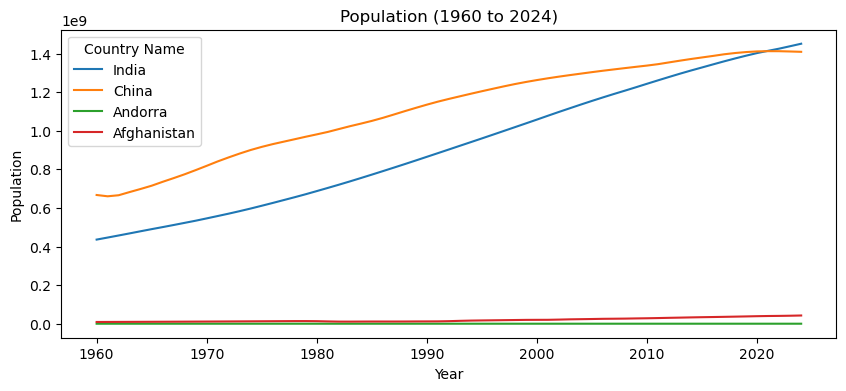

In [9]:
df_pivot.plot(kind='line',xlabel='Year',ylabel='Population',
              title = 'Population (1960 to 2024)',
              figsize=(10,4))

# 3 Barplot

### 3.1  Single Barplot

In [10]:
# select only one year(2024)
df_pivot_2024 = df_pivot[df_pivot.index.isin([2024])]

In [11]:
# showing a new dataframe
df_pivot_2024

Country Name,India,China,Andorra,Afghanistan
Year,,,,
2024,1.450936e+09,1.408975e+09,81938.0,42647492.0


In [12]:
# Transpose dataframe from rows to columns or viceversa
df_pivot_2024 = df_pivot_2024.T

<Axes: title={'center': 'population(2024)'}, xlabel='Country Name', ylabel='population'>

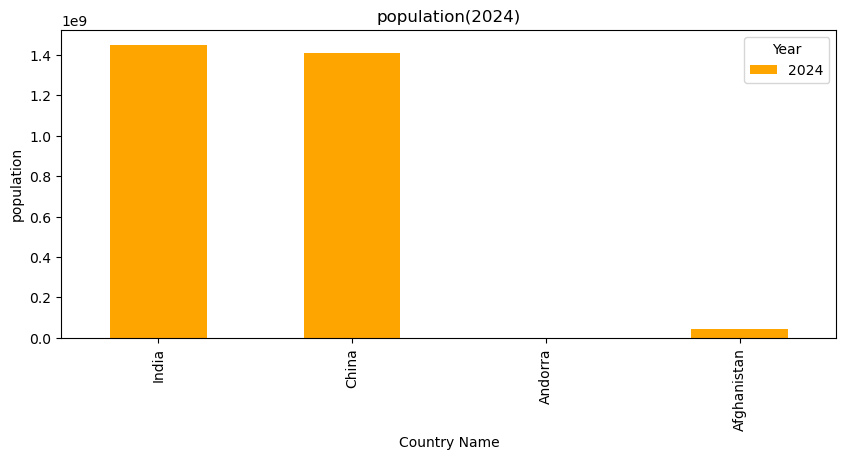

In [13]:
# making Barplot
df_pivot_2024.plot(kind='bar',
                   xlabel = 'Country Name',
                   ylabel = 'population',
                   title ='population(2024)',
                   figsize=(10,4),
                   color='Orange')

# 3.2 Barplot ground by “n“ variables

In [14]:
# selecting a few year
df_pivot_sample = df_pivot[df_pivot.index.isin([1974,1984,1994,2004,2014,2024])]

In [15]:
df_pivot_sample

Country Name,India,China,Andorra,Afghanistan
Year,,,,
1974,5.970414e+08,9.003500e+08,26130.0,12469127.0
1984,7.548754e+08,1.036825e+09,42273.0,11190221.0
1994,9.411638e+08,1.191835e+09,64612.0,16250794.0
2004,1.135992e+09,1.296075e+09,74325.0,23560654.0
2014,1.312277e+09,1.371860e+09,73737.0,32792523.0
2024,1.450936e+09,1.408975e+09,81938.0,42647492.0


<Axes: title={'center': 'population(2024)'}, xlabel='Country Name', ylabel='population'>

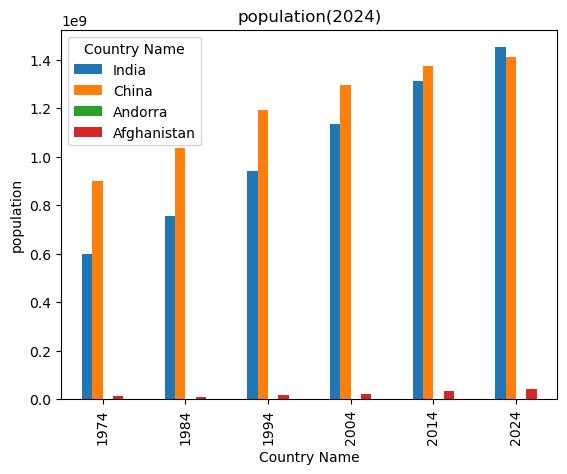

In [16]:
# making grounped barplot
df_pivot_sample.plot(kind='bar',
                    xlabel = 'Country Name',
                   ylabel = 'population',
                   title ='population(2024)')

# 4 piechart

In [17]:
# changing columns names
df_pivot_2024.rename(columns={2024:'2024'},inplace=True)

<Axes: ylabel='2024'>

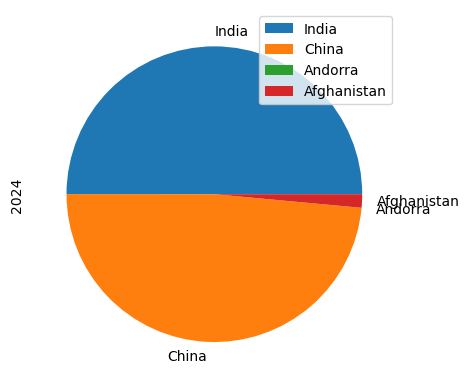

In [18]:
# making the plot
df_pivot_2024.plot(kind='pie',y='2024')

# 5. Boxplot

# 5.1 Single Boxplot

<Axes: ylabel='population'>

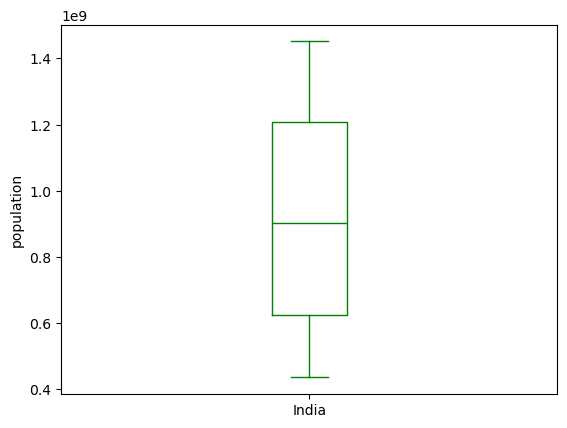

In [19]:
df_pivot['India'].plot(kind='box', ylabel= 'population',color='green')

# 5.2 multiple Boxplot 

<Axes: ylabel='population'>

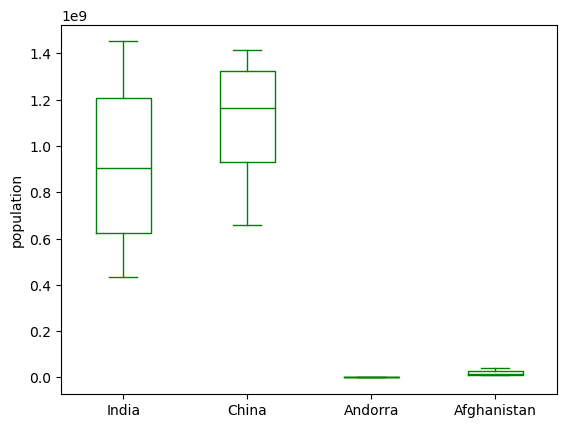

In [20]:
df_pivot.plot(kind='box', ylabel= 'population',color='green')

# 6 Histogram

<Axes: ylabel='Frequency'>

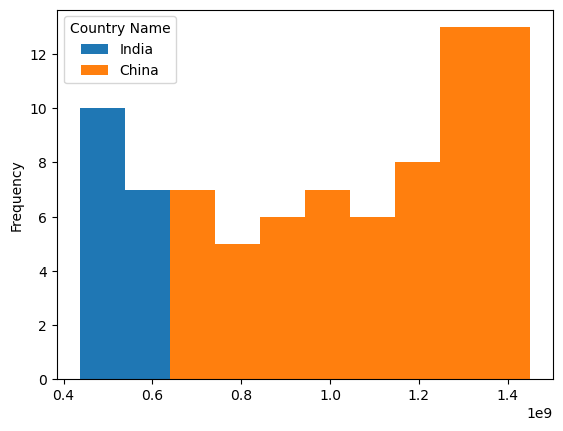

In [21]:
df_pivot[['India','China']].plot(kind='hist')

# 7 Scatterplot 

In [22]:
# selecting a simple of the raw data
df_sample = df_population_row[df_population_row['Country Name'].isin(['India','China','Viet Nam','Zimbabwe'])]

<Axes: xlabel='Year', ylabel='Value'>

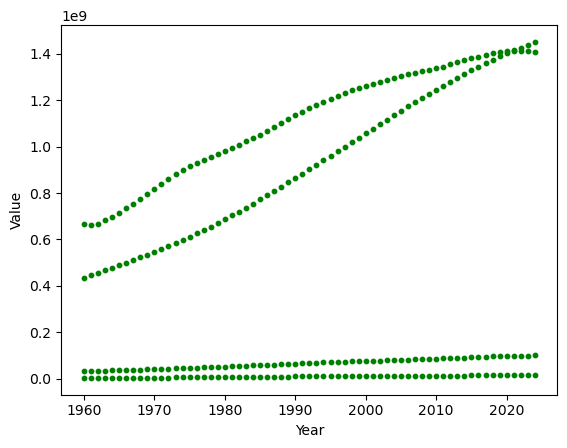

In [23]:
# Creating the plot
df_sample.plot(kind='scatter',
               x='Year',
               y='Value',
               s=10,
               color='green')